# 🌱 Crop Disease Detection and Environmental Monitoring

This project combines:

1. Pretrained deep learning-based plant disease detection
2. Leaf image classification using EfficientNet-B4
3. Physical environmental sensor data
4. Temperature monitoring
5. Soil-moisture monitoring
6. Environmental context analysis
7. Integrated crop-health reporting

The pretrained image classification model used in this project is
the Khawajaa Plant Disease Detector based on EfficientNet-B4.

The image model predicts plant disease from the leaf image.
Temperature and soil-moisture measurements are collected separately
through physical sensors and are used as environmental context.

In [1]:
!pip install -q huggingface_hub torchvision pillow matplotlib opencv-python

In [2]:
import os
import sys
import json
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from datetime import datetime
from torchvision import transforms
from huggingface_hub import hf_hub_download

In [3]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("Running on CPU")
    device = torch.device("cpu")

print("Selected device:", device)

PyTorch version: 2.11.0+cpu
CUDA available: False
Running on CPU
Selected device: cpu


In [4]:
MODEL_REPO = "Khawajaa/plant-disease-detector"
MODEL_FILENAME = "best_model.pth"

model_path = hf_hub_download(
    repo_id=MODEL_REPO,
    filename=MODEL_FILENAME
)

print("Pretrained model downloaded successfully.")
print("Model path:", model_path)

best_model.pth: reconstructing file:   0%|          |  0.00B / 74.7MB            

best_model.pth: downloading bytes:           |  0.00B            

Pretrained model downloaded successfully.
Model path: /root/.cache/huggingface/hub/models--Khawajaa--plant-disease-detector/snapshots/3fc448a4080eca42e1540ba8a672f1682110d798/best_model.pth


In [5]:
if not os.path.exists("/content/plant-disease-detector"):
    !git clone https://github.com/khawaja1447/plant-disease-detector.git

sys.path.append("/content/plant-disease-detector")

from src.model import EfficientNetB4Classifier

print("EfficientNet-B4 architecture imported successfully.")

Cloning into 'plant-disease-detector'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 96 (delta 27), reused 91 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 2.09 MiB | 5.34 MiB/s, done.
Resolving deltas: 100% (27/27), done.
EfficientNet-B4 architecture imported successfully.


In [6]:
model = EfficientNetB4Classifier(
    num_classes=38,
    pretrained=False
)

checkpoint = torch.load(
    model_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Khawajaa pretrained model loaded successfully.")
print("Number of classes:", 38)
print("Device:", device)

Khawajaa pretrained model loaded successfully.
Number of classes: 38
Device: cpu


In [7]:
CLASS_NAMES = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___Cedar_apple_rust",
    "Apple___healthy",

    "Blueberry___healthy",

    "Cherry___Powdery_mildew",
    "Cherry___healthy",

    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___Common_rust",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Corn_(maize)___healthy",

    "Grape___Black_rot",
    "Grape___Esca_(Black_Measles)",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)",
    "Grape___healthy",

    "Orange___Haunglongbing_(Citrus_greening)",

    "Peach___Bacterial_spot",
    "Peach___healthy",

    "Pepper,_bell___Bacterial_spot",
    "Pepper,_bell___healthy",

    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",

    "Raspberry___healthy",

    "Soybean___healthy",

    "Squash___Powdery_mildew",

    "Strawberry___Leaf_scorch",
    "Strawberry___healthy",

    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___healthy"
]

print("Number of classes:", len(CLASS_NAMES))

Number of classes: 38


In [8]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image preprocessing pipeline ready.")

Image preprocessing pipeline ready.


Saving tomato_leaf_spot.jpg to tomato_leaf_spot.jpg
Image: tomato_leaf_spot.jpg
Original size: (448, 684)
Image mode: RGB


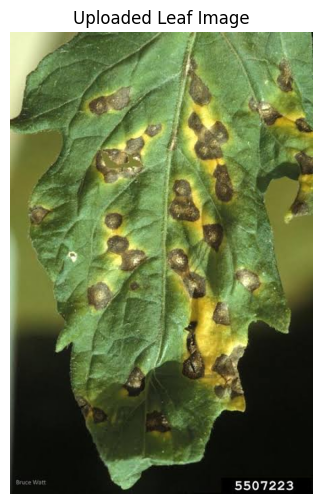

In [9]:
from google.colab import files

uploaded = files.upload()

image_filename = list(uploaded.keys())[0]

image = Image.open(
    image_filename
).convert("RGB")

print("Image:", image_filename)
print("Original size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Uploaded Leaf Image")
plt.show()

In [10]:
def predict_leaf(image):
    """
    Predict plant disease from a leaf image
    using the Khawajaa pretrained EfficientNet-B4 model.
    """

    image = image.convert("RGB")

    input_tensor = transform(image)
    input_tensor = input_tensor.unsqueeze(0)
    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)

    top_probs, top_indices = torch.topk(
        probabilities,
        k=5,
        dim=1
    )

    results = []

    for i in range(5):
        index = top_indices[0][i].item()
        probability = top_probs[0][i].item()

        results.append({
            "class": CLASS_NAMES[index],
            "confidence": probability
        })

    predicted_class = results[0]["class"]
    confidence = results[0]["confidence"]

    return predicted_class, confidence, results

In [11]:
predicted_class, confidence, top_predictions = predict_leaf(
    image
)

print("Predicted class:", predicted_class)
print(
    "Confidence:",
    f"{confidence * 100:.2f}%"
)

Predicted class: Tomato___Early_blight
Confidence: 66.81%


In [12]:
print("TOP 5 PREDICTIONS")
print("-" * 60)

for i, result in enumerate(top_predictions, start=1):

    readable_class = (
        result["class"]
        .replace("___", " - ")
        .replace("_", " ")
    )

    print(
        f"{i}. {readable_class}"
        f" — {result['confidence'] * 100:.2f}%"
    )

TOP 5 PREDICTIONS
------------------------------------------------------------
1. Tomato - Early blight — 66.81%
2. Tomato - Late blight — 32.93%
3. Potato - Early blight — 0.18%
4. Tomato - Septoria leaf spot — 0.05%
5. Pepper, bell - Bacterial spot — 0.03%


In [13]:
def format_prediction(class_name):

    plant, condition = class_name.split("___", 1)

    plant = plant.replace("_", " ")
    condition = condition.replace("_", " ")

    return plant, condition


plant, condition = format_prediction(
    predicted_class
)

print("Plant:", plant)
print("Condition:", condition)

Plant: Tomato
Condition: Early blight


In [14]:
if "healthy" in predicted_class.lower():
    image_status = "Healthy class predicted"
else:
    image_status = "Potential disease detected"

print("Image assessment:", image_status)

Image assessment: Potential disease detected


Temperature Sensor
       │
       ▼
      ESP32
       │
       ▼
Python application

Soil Moisture Sensor
       │
       ▼
      ESP32
       │
       ▼
Python application

In [20]:
!pip install pyserial

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 4.0 MB/s eta 0:00:00


In [22]:
#NEED NOT BE REFERED IN THE FINAL THING THAT WILL BE ALONG WITH ESP32
def get_sensor_data():
    """
    Temporary sensor interface.

    Currently returns simulated values.
    This function will later be connected to the
    actual ESP32 communication layer.
    """

    temperature_c = 28.4
    soil_moisture_pct = 68.0

    return {
        "temperature_c": temperature_c,
        "soil_moisture_pct": soil_moisture_pct,
        "source": "simulation"
    }

In [21]:
import serial
import json

# Change this to your ESP32's serial port
SERIAL_PORT = "COM3"
BAUD_RATE = 115200

esp32 = serial.Serial(
    SERIAL_PORT,
    BAUD_RATE,
    timeout=2
)


def read_from_esp32():

    line = esp32.readline().decode("utf-8").strip()

    if not line:
        raise RuntimeError("No data received from ESP32.")

    data = json.loads(line)

    return data

SerialException: [Errno 2] could not open port COM3: [Errno 2] No such file or directory: 'COM3'

In [17]:
def get_sensor_data():

    # Receive data from ESP32
    data = read_from_esp32()

    temperature_c = data["temperature"]
    soil_moisture_pct = data["soil_moisture"]

    return {
        "temperature_c": temperature_c,
        "soil_moisture_pct": soil_moisture_pct,
        "source": "ESP32"
    }

In [19]:
sensor_data = get_sensor_data()

temperature = sensor_data["temperature_c"]
soil_moisture = sensor_data["soil_moisture_pct"]

print("ENVIRONMENTAL SENSOR DATA")
print("-" * 40)

print(f"Temperature   : {temperature:.1f} °C")
print(f"Soil Moisture : {soil_moisture:.1f} %")
print(f"Data Source   : {sensor_data['source']}")

NameError: name 'read_from_esp32' is not defined

In [23]:
def validate_sensor_data(
    temperature,
    soil_moisture
):

    errors = []

    if temperature is None:
        errors.append("Temperature reading unavailable.")

    elif not -10 <= temperature <= 60:
        errors.append(
            "Temperature reading is outside the expected sensor range."
        )

    if soil_moisture is None:
        errors.append(
            "Soil-moisture reading unavailable."
        )

    elif not 0 <= soil_moisture <= 100:
        errors.append(
            "Soil-moisture percentage is invalid."
        )

    return errors

In [24]:
sensor_errors = validate_sensor_data(
    temperature,
    soil_moisture
)

if sensor_errors:
    print("Sensor validation warnings:")

    for error in sensor_errors:
        print("-", error)

else:
    print("Sensor readings validated successfully.")

Sensor readings validated successfully.


In [26]:
def analyze_environment(
    temperature,
    soil_moisture
):

    observations = []

    # Temperature description
    if temperature < 15:

        observations.append(
            "Measured temperature is relatively low."
        )

    elif temperature <= 30:

        observations.append(
            "Measured temperature is within a moderate range."
        )

    else:

        observations.append(
            "Measured temperature is relatively high."
        )

    # Soil moisture description
    if soil_moisture < 30:

        observations.append(
            "Measured soil moisture is relatively low."
        )

    elif soil_moisture <= 70:

        observations.append(
            "Measured soil moisture is within a moderate range."
        )

    else:

        observations.append(
            "Measured soil moisture is relatively high."
        )

    overall = (
        "The sensor readings provide environmental context "
        "for the image-based disease prediction. "
        "They should not be interpreted as proof of disease."
    )

    return observations, overall

In [27]:
observations, environmental_summary = analyze_environment(
    temperature,
    soil_moisture
)

print("ENVIRONMENTAL CONTEXT")
print("-" * 50)

for observation in observations:
    print("•", observation)

print("\nSummary:")
print(environmental_summary)

ENVIRONMENTAL CONTEXT
--------------------------------------------------
• Measured temperature is within a moderate range.
• Measured soil moisture is within a moderate range.

Summary:
The sensor readings provide environmental context for the image-based disease prediction. They should not be interpreted as proof of disease.


In [28]:
analysis_result = {

    "timestamp":
        datetime.now().strftime(
            "%d-%m-%Y %H:%M:%S"
        ),

    "image": image_filename,

    "plant": plant,

    "predicted_condition": condition,

    "predicted_class": predicted_class,

    "confidence": confidence,

    "image_assessment": image_status,

    "top_predictions": top_predictions,

    "environment": {

        "temperature_c": temperature,

        "soil_moisture_pct": soil_moisture,

        "source": sensor_data["source"]
    },

    "environmental_observations":
        observations,

    "environmental_summary":
        environmental_summary
}

analysis_result

{'timestamp': '28-09-2026 18:11:58',
 'image': 'tomato_leaf_spot.jpg',
 'plant': 'Tomato',
 'predicted_condition': 'Early blight',
 'predicted_class': 'Tomato___Early_blight',
 'confidence': 0.6680940985679626,
 'image_assessment': 'Potential disease detected',
 'top_predictions': [{'class': 'Tomato___Early_blight',
   'confidence': 0.6680940985679626},
  {'class': 'Tomato___Late_blight', 'confidence': 0.32929763197898865},
  {'class': 'Potato___Early_blight', 'confidence': 0.0017834887839853764},
  {'class': 'Tomato___Septoria_leaf_spot',
   'confidence': 0.0005207666545175016},
  {'class': 'Pepper,_bell___Bacterial_spot',
   'confidence': 0.00027106195921078324}],
 'environment': {'temperature_c': 28.4,
  'soil_moisture_pct': 68.0,
  'source': 'simulation'},
 'environmental_observations': ['Measured temperature is within a moderate range.',
  'Measured soil moisture is within a moderate range.'],
 'environmental_summary': 'The sensor readings provide environmental context for the ima

In [29]:
def confidence_message(confidence):

    if confidence < 0.50:

        return (
            "Low model confidence. "
            "Manual inspection is strongly recommended."
        )

    elif confidence < 0.75:

        return (
            "Moderate model confidence. "
            "The prediction should be verified manually."
        )

    else:

        return (
            "Higher model confidence. "
            "The prediction should still be verified "
            "against the actual leaf."
        )


confidence_note = confidence_message(
    confidence
)

print(confidence_note)

Moderate model confidence. The prediction should be verified manually.


In [30]:
report = f"""
============================================================
                 🌱 CROP HEALTH REPORT
============================================================

Report Generated:
{analysis_result["timestamp"]}

------------------------------------------------------------
IMAGE INFORMATION
------------------------------------------------------------

Image:
{image_filename}

Plant:
{plant.title()}

Predicted Condition:
{condition.title()}

Image Assessment:
{image_status}

Model:
Khawajaa Plant Disease Detector
EfficientNet-B4

Model Confidence:
{confidence * 100:.2f}%

Confidence Interpretation:
{confidence_note}

------------------------------------------------------------
TOP 5 MODEL PREDICTIONS
------------------------------------------------------------

"""

for i, result in enumerate(
    top_predictions,
    start=1
):

    readable = (
        result["class"]
        .replace("___", " - ")
        .replace("_", " ")
    )

    report += (
        f"{i}. {readable}"
        f" — {result['confidence'] * 100:.2f}%\n"
    )


report += f"""
------------------------------------------------------------
PHYSICAL SENSOR DATA
------------------------------------------------------------

Temperature:
{temperature:.1f} °C

Soil Moisture:
{soil_moisture:.1f} %

Sensor Data Source:
{sensor_data["source"]}

------------------------------------------------------------
ENVIRONMENTAL CONTEXT
------------------------------------------------------------

"""

for observation in observations:

    report += f"• {observation}\n"


report += f"""

Environmental Summary:

{environmental_summary}

------------------------------------------------------------
RECOMMENDED NEXT STEP
------------------------------------------------------------

Inspect the affected leaf and verify the model prediction
using appropriate crop-specific disease information.

Environmental sensor readings are provided as supporting
context and are not themselves a disease diagnosis.

------------------------------------------------------------
SYSTEM LIMITATION
------------------------------------------------------------

The disease prediction is based on the uploaded leaf image.
Temperature and soil moisture are separate environmental
measurements.

The current system does not use sensor measurements as inputs
to the EfficientNet-B4 classifier.

------------------------------------------------------------
============================================================
"""

print(report)


                 🌱 CROP HEALTH REPORT

Report Generated:
28-09-2026 18:11:58

------------------------------------------------------------
IMAGE INFORMATION
------------------------------------------------------------

Image:
tomato_leaf_spot.jpg

Plant:
Tomato

Predicted Condition:
Early Blight

Image Assessment:
Potential disease detected

Model:
Khawajaa Plant Disease Detector
EfficientNet-B4

Model Confidence:
66.81%

Confidence Interpretation:
Moderate model confidence. The prediction should be verified manually.

------------------------------------------------------------
TOP 5 MODEL PREDICTIONS
------------------------------------------------------------

1. Tomato - Early blight — 66.81%
2. Tomato - Late blight — 32.93%
3. Potato - Early blight — 0.18%
4. Tomato - Septoria leaf spot — 0.05%
5. Pepper, bell - Bacterial spot — 0.03%

------------------------------------------------------------
PHYSICAL SENSOR DATA
------------------------------------------------------------

Te

In [31]:
report_filename = "crop_health_report.txt"

with open(
    report_filename,
    "w",
    encoding="utf-8"
) as file:

    file.write(report)

print(
    "Report saved as:",
    report_filename
)

Report saved as: crop_health_report.txt


In [32]:
from google.colab import files

files.download(
    report_filename
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
json_filename = "crop_analysis_result.json"

with open(
    json_filename,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        analysis_result,
        file,
        indent=4
    )

print(
    "Structured analysis saved as:",
    json_filename
)

Structured analysis saved as: crop_analysis_result.json


In [34]:
print("""
============================================================
              FINAL SYSTEM PIPELINE
============================================================

1. Leaf Image
       ↓
2. Image Preprocessing
       ↓
3. Khawajaa EfficientNet-B4
       ↓
4. Disease Prediction
       ↓
5. Confidence + Top-5 Predictions

                    +

6. Temperature Sensor
       ↓
7. ESP32
       ↓
8. Temperature Reading

                    +

9. Soil Moisture Sensor
       ↓
10. ESP32
       ↓
11. Soil Moisture Reading

                    ↓

12. Environmental Context Analysis
                    ↓
13. Integrated Crop Health Report
                    ↓
14. Export / Application UI

============================================================
""")


              FINAL SYSTEM PIPELINE

1. Leaf Image
       ↓
2. Image Preprocessing
       ↓
3. Khawajaa EfficientNet-B4
       ↓
4. Disease Prediction
       ↓
5. Confidence + Top-5 Predictions

                    +

6. Temperature Sensor
       ↓
7. ESP32
       ↓
8. Temperature Reading

                    +

9. Soil Moisture Sensor
       ↓
10. ESP32
       ↓
11. Soil Moisture Reading

                    ↓

12. Environmental Context Analysis
                    ↓
13. Integrated Crop Health Report
                    ↓
14. Export / Application UI


